# Separation of the data
In this section, the original defungi dataset is divided into 80% training and 20% testing. The images are copied into a new folder structure while preserving the original class folders.

In [2]:
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path
import random
import shutil

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
source_path = Path("/content/drive/MyDrive/TC3002/defungi")
separation_path = Path("/content/drive/MyDrive/TC3002/defungi_separation")

# % for training
training_percentage = 0.80

# Valid extensions
image_extensions = [".jpg", ".jpeg", ".png", ".bmp"]

# Seed to reproduce the separation in future executions
random.seed(10)

In [8]:
#Create folders training and test
training_path = separation_path / "training"
test_path = separation_path / "test"

training_path.mkdir(parents=True, exist_ok=True)
test_path.mkdir(parents=True, exist_ok=True)

In [10]:
#Function to get valid images
def get_image_files(folder_path):
    image_files = []

    for file in folder_path.iterdir():
        if file.suffix.lower() in image_extensions:
            image_files.append(file)

    return image_files


#Function to copy the images
def copy_images(image_list, destination_folder):
    destination_folder.mkdir(parents=True, exist_ok=True)

    for image_path in image_list:
        destination_path = destination_folder / image_path.name
        shutil.copy(image_path, destination_path)

for category_folder in source_path.iterdir():

    if not category_folder.is_dir():
        continue

    category_name = category_folder.name

    images = get_image_files(category_folder)
    random.shuffle(images)

    total_images = len(images)
    training_count = int(total_images * training_percentage)

    training_images = images[:training_count]
    test_images = images[training_count:]

    copy_images(training_images, training_path / category_name)
    copy_images(test_images, test_path / category_name)

    print(f"Category: {category_name}")
    print(f"Total of images: {total_images}")
    print(f"Training: {len(training_images)}")
    print(f"Test: {len(test_images)}")
    print("-" * 30)

print("Separation for training and test (80/20) ready.")

Category: H5
Total of images: 818
Training: 654
Test: 164
------------------------------
Category: H2
Total of images: 2334
Training: 1867
Test: 467
------------------------------
Category: H3
Total of images: 819
Training: 655
Test: 164
------------------------------
Category: H1
Total of images: 4404
Training: 3523
Test: 881
------------------------------
Category: H6
Total of images: 739
Training: 591
Test: 148
------------------------------
Separation for training and test (80/20) ready.


# Preprocessing, scaling, and data augmentation
In this section, the separated dataset is loaded using Keras. The training set receives scaling and data augmentation, while the test set only receives scaling.

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [18]:
img_height = 128
img_width = 128
batch_size = 32

training_path = "/content/drive/MyDrive/TC3002/defungi_separation/training"
test_path = "/content/drive/MyDrive/TC3002/defungi_separation/test"

In [27]:
training_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [28]:
training_generator = training_datagen.flow_from_directory(
    training_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="sparse"

)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="sparse"
)

Found 7290 images belonging to 5 classes.
Found 1824 images belonging to 5 classes.


In [21]:
print(training_generator.class_indices)

{'H1': 0, 'H2': 1, 'H3': 2, 'H5': 3, 'H6': 4}


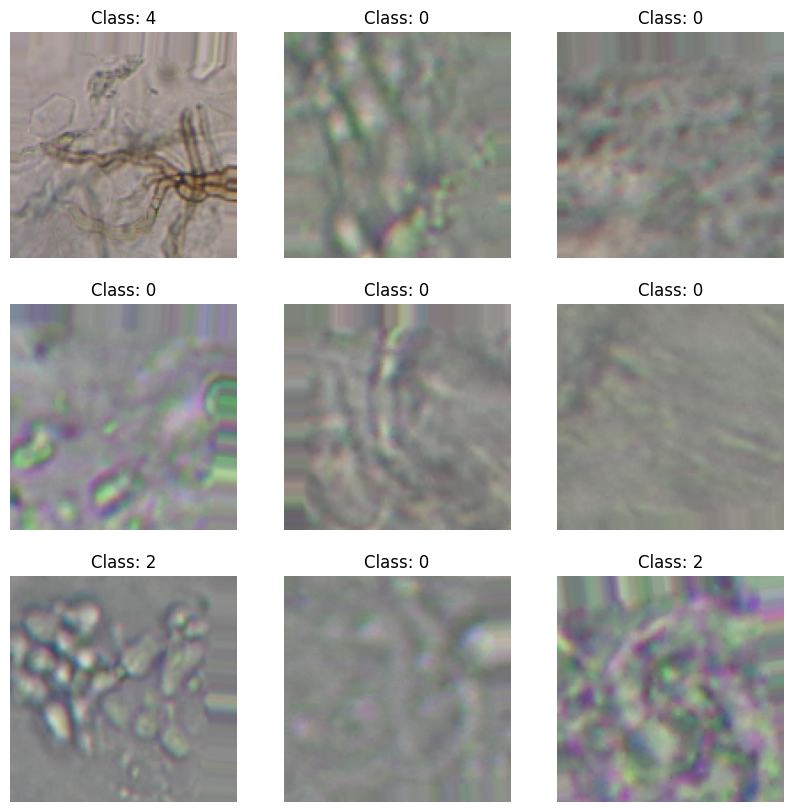

In [26]:
images, labels = next(training_generator)

plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title("Class: " + str(int(labels[i])))
    plt.axis("off")

plt.show()

In [30]:
print("Processing Summary:")
print("Training images:", training_generator.samples)
print("Test images:", test_generator.samples)
print("Classes:", training_generator.class_indices)
print("Image size:", img_height, "x", img_width)
print("Batch size:", batch_size)

Processing Summary:
Training images: 7290
Test images: 1824
Classes: {'H1': 0, 'H2': 1, 'H3': 2, 'H5': 3, 'H6': 4}
Image size: 128 x 128
Batch size: 32
